In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.head(8)

,StudyHours,Attendance,Assignments,Participation,Result
0,High,Good,Complete,High,Pass
1,Medium,Good,Complete,Medium,Pass
2,Low,Poor,Incomplete,Low,Fail
3,High,Average,Complete,High,Pass
4,Medium,Average,Partial,Medium,Pass
5,Low,Poor,Partial,Low,Fail
6,High,Good,Complete,Medium,Pass
7,Medium,Good,Partial,High,Pass


In [4]:
df.dtypes

StudyHours       str
Attendance       str
Assignments      str
Participation    str
Result           str
dtype: object

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df = df.apply(le.fit_transform)

In [6]:
df.head(7)

,StudyHours,Attendance,Assignments,Participation,Result
0,0,1,0,0,1
1,2,1,0,2,1
2,1,2,1,1,0
3,0,0,0,0,1
4,2,0,2,2,1
5,1,2,2,1,0
6,0,1,0,2,1


In [7]:
X = df.drop(['Result'],axis=1)
X.head()

,StudyHours,Attendance,Assignments,Participation
0,0,1,0,0
1,2,1,0,2
2,1,2,1,1
3,0,0,0,0
4,2,0,2,2


In [8]:
y = df['Result']
y.head()

0    1
1    1
2    0
3    1
4    1
Name: Result, dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
model = DecisionTreeClassifier()

In [17]:
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [19]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

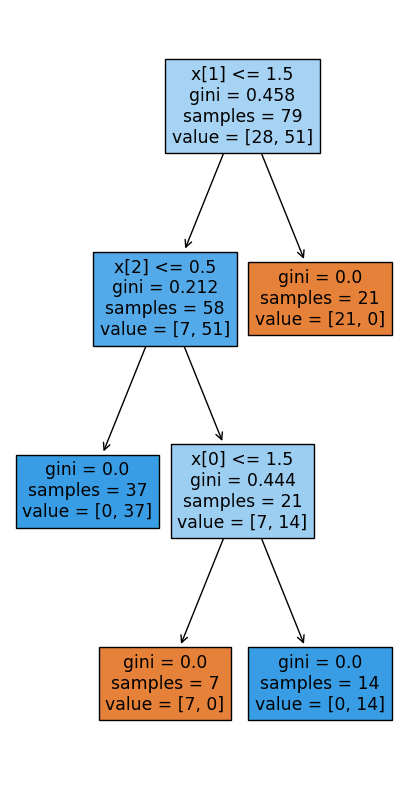

In [24]:
plt.figure(figsize=(5,10))
plot_tree(model, filled = True)
plt.show()

In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1])

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
accuracy = accuracy_score(y_test, y_pred)

In [34]:
print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100)

Accuracy: 1.0
Accuracy Percentage: 100.0


In [35]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 5  0]
 [ 0 15]]


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        15

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [38]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

Cross Validation Scores: [1. 1. 1. 1. 1.]
Average Accuracy: 1.0


In [39]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv)

print("10-Fold CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Std Dev:", scores.std())

10-Fold CV Scores: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Mean Accuracy: 1.0
Std Dev: 0.0
